In [75]:
using Plots, Measures, LaTeXStrings, Latexify, DataFrames, CSV, Dates, Statistics, Distributions

In [77]:
gr()
theme(:ggplot2)
default(size = (1200,700),left_margin = 10mm, top_margin = 15mm,bottom_margin = 10mm, 
    guidefontsize=18, tickfontsize=14, legendfontsize = 18, framestyle = :box,
     foreground_color_border = :black)

#### Labo 2
##### Modelito de péndulo ideal:

* Tiene una masa puntual $m$ que oscila en un extremo de un hilo inextensible y sin masa de largo $\ell$.
* No tiene fricción alguna.
* Oscila a bajas amplitudes.
  
**Si lo anterior se cumple**, entonces:

$$
\tau = 2\pi \sqrt{\frac{\ell}{g}}
$$


##### Corroborar el modelo es medir ambos lados de la igualdad (y suponer $g_{RAGA}$).

* Medimos $\tau$, medimos $\ell$

1. Pensamos en errores sistemáticos (y actuamos en consecuencia).
2. Pensamos en incertezas o errores aleatorios (y actuamos en consecuencia).

Para corroborar el modelo, en general, intentamos un rango de $\ell$ y vemos la relación funcional.

1. Sólo en un rango se ven problemas de errores sistemáticos.
2. Sólo en un rango se puede ver la *funcionalidad*, ***id est*** (i.e.): $\tau \propto \sqrt{\ell}$



 **Para cada medida la cuestión es:**

1. ¿Estos resultados, tienen ***sesgos***? Si tienen sesgo, ¿cuál sería? (positivo o negativo respecto del valor informado/anotado)
1. ¿Usamos todos los datos para sacar la media o hacemos alguna limpieza?
1. Si usamos la media muestral como estimador de $\tau$, ¿qué usamos como incerteza?

De antemano:
* $\ell$ lo medimos con una cinta métrica (en principo tendremos una incerteza $\pm 1\; mm$). Esta incerteza es *modelada* por una distribución *triangular* (la resta de dos distribuciones *uniformes*).

* $\tau$ se obtiene por 200 repeticiones. Esto nos permitirá obtener una distribución de valores, calcular la media y la desviación estándar y el SEM. Este tipo de medida es, en principio, más *robusta*.

Vamos a cada caso...

### $\ell \pm \delta\ell$

* Asumamos que la cinta métrica está *calibrada*, es decir, cada milímetro es un milímetro patrón.

  ¿Qué pasa si medimos fuera de la vertical una distancia?

Lógica consecuencia: los valores de $\ell$ pueden tener un error sitemático positivo ($\ell_{medido} > \ell_{real}$).

La incerteza de 1mm no la vamos a mover, pero tener en cuenta que el valor central informado *podría ser un poquito mayor* de lo que realmente es.

In [3]:
l = 3.450; δl = 0.001;

***
***
### $\tau \pm SEM_{tau}$

* Ustedes se utilizaron como instrumento de medida (sistema nervioso central + ojos + respuesta motora).
* La primera pregunta es


**¿esto introduce *sesgos* (errores sistemáticos) en la medición?**

Hagamos unos gráficos y discutamos los resultados.

In [4]:
data = CSV.read("/home/juan/Documentos/Docencia/fexpi/2026/Datos/Labo2/Nico.csv", header = 2, DataFrame);
rename!(data,:" <Lap Time>" => :p); print(first(data,4))
τ = Dates.value.(data.p)/1E9; first(τ,5) #convertimos a una variable en segundos para operar

4×3 DataFrame
 Row │ <Lap>     p             <Total Time> 
     │ String15  Time         Time          
─────┼──────────────────────────────────────
   1 │ Vuelta 1  00:00:03.37  00:00:03.37
   2 │ Vuelta 2  00:00:03.6   00:00:06.97
   3 │ Vuelta 3  00:00:04.12  00:00:11.1
   4 │ Vuelta 4  00:00:03.58  00:00:14.69

5-element Vector{Float64}:
 3.37
 3.6
 4.12
 3.58
 3.76

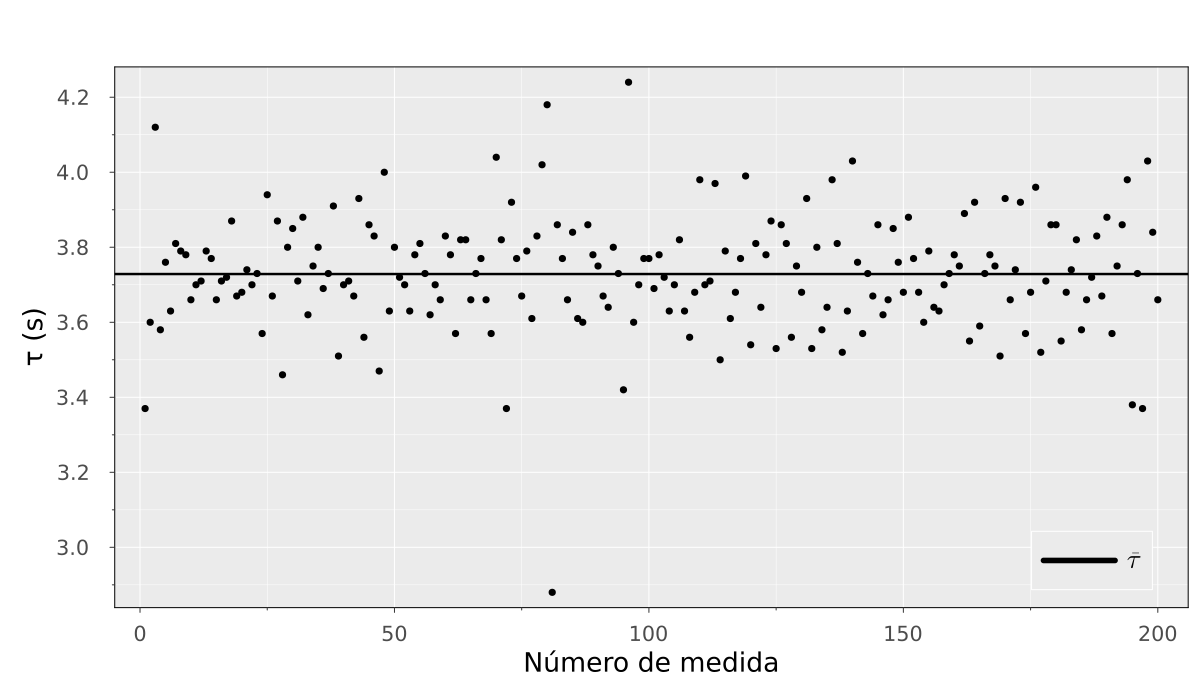

In [7]:
scatter(τ, color = :black ,ylabel = "τ (s)", xlabel = "Número de medida", label = false)
hline!([mean(τ)], color = :black, linewidth = 2.5, label = L"\mathbf{\bar{\tau}}")

Vemos que:
* Nico mide muy bien, pero no siempre lo mismo (es esperable y pasa con muchos sensores, incluso humanos).
* Hay un punto debajo de $\tau = 3s$ en el que Nico se "apuró a apretar", el cual debemos sacar.erra

En general, a todas las medidas hay que ***limpiarlas***, porque los datos que son errores ***sesgan*** los estimadores:

* La media se sega un poco, porque no es un estimador robusto (sub o sobreestimando valores centrales).
* La desviación estándar es menos robusta y se sesga más (sobreestimando incertezas).

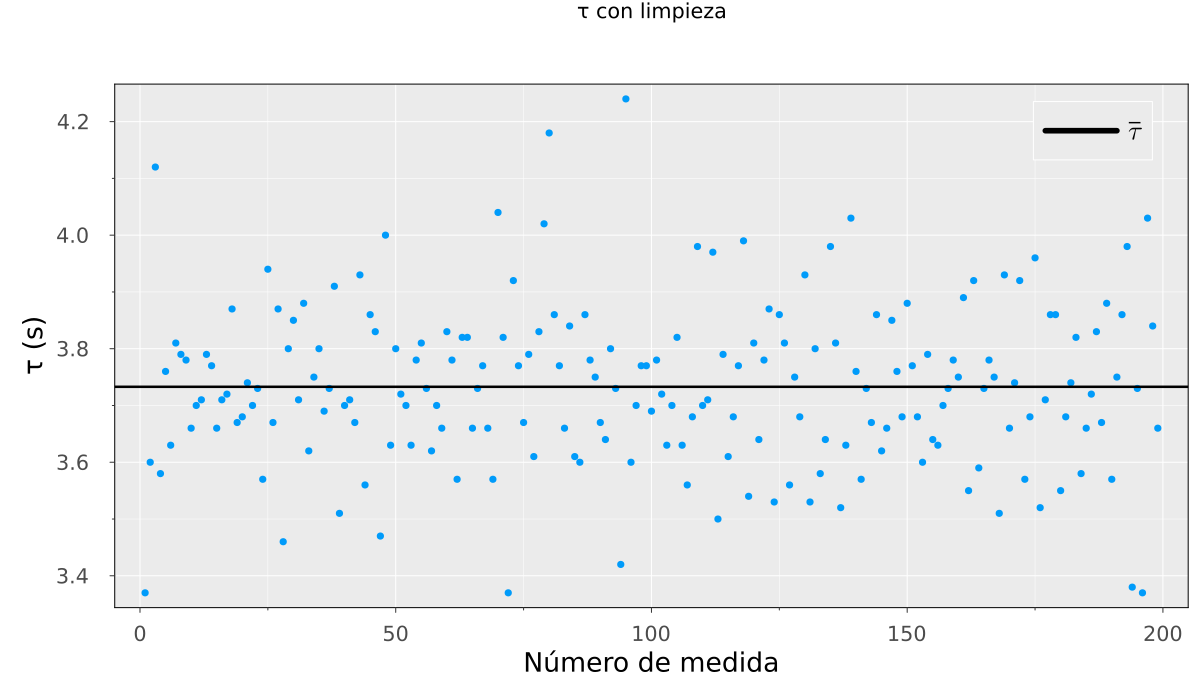

In [79]:
τl = τ[τ .> 3];
scatter(τl, ylabel = "τ (s)", xlabel = "Número de medida", title = "τ con limpieza",label = false)
hline!([mean(τl)], color = :black, linewidth = 2.5, label = L"\overline{\tau}")

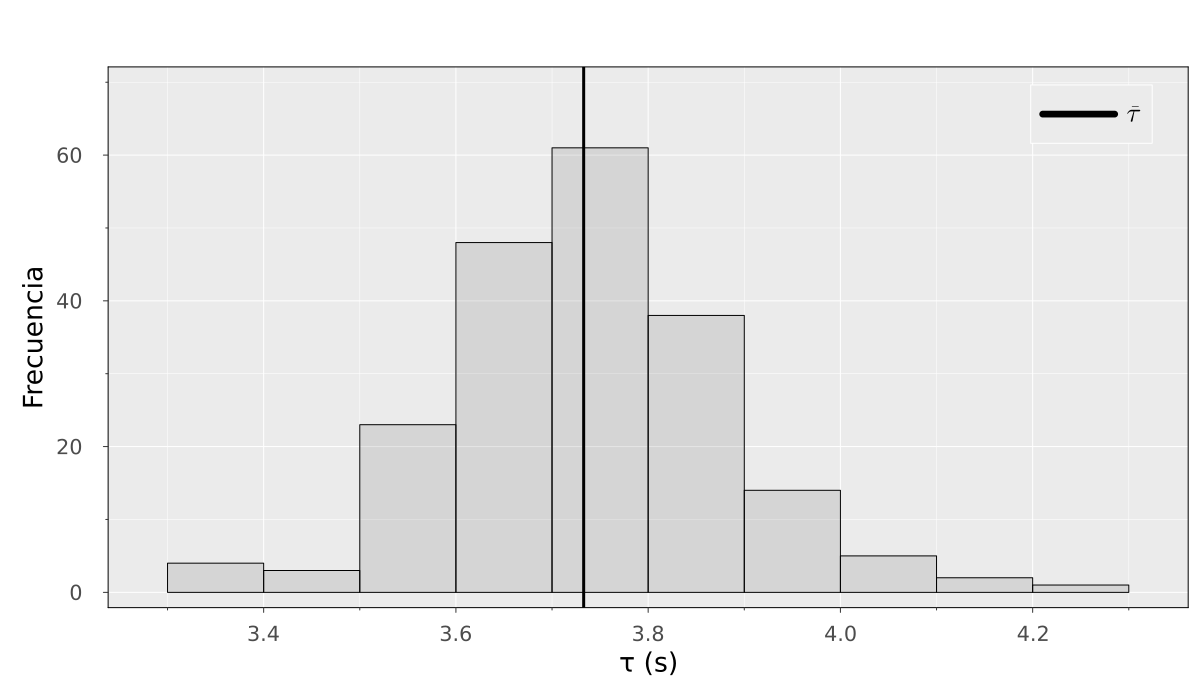

In [11]:
histogram(τl, color = :gray, fillalpha = 0.2,bins = :sturges, ylim = (0,70), label = false, xlab = "τ (s)", ylab = "Frecuencia")
vline!([mean(τl)], color = :black, linewidth = 3, label = L"\mathbf{\bar{\tau}}")

 Ahora, luego de sacar el punto problemático, ya tenemos nuestra medida de perodos resumida como:

In [21]:
st = std(τl); media = mean(τl); SEM = std(τl)/sqrt(length(τl)); string(L"\bar{\tau} =  %$media s  \quad s_{\tau} =  %$st s \quad SEM_{\tau} =  %$SEM")

L"$\bar{\tau} =  3.732914572864322 s  \quad s_{\tau} =  0.1439295132575632 s \quad SEM_{\tau} =  0.010202892679428466$"

#### Evaluando el modelo para un punto

En la guía pide calcular la aceleración de la gravedad y comprarla, pero si asumimos $g_{RAGA} =  9.79316985 m s^{-2}$ podemos calcular directamente ambos lados de la ec.:

$$\tau = 2\pi \sqrt{\frac{\ell}{g}}$$


Para Nicolás, tenemos que $\bar{\tau} = 3.733\; s$, por lo que el lado derecho de la ecuación anterior nos da un periodo:

In [78]:
g_raga = 9.79316985;
τ_modelo = 2*pi*sqrt(l/g_raga);
string(L"\tau_{Modelo} = %$τ_modelo \; s \;\quad \bar{\tau} = %$media \; s")

L"$\tau_{Modelo} = 3.7293038752764804 \; s \;\quad \bar{\tau} = 3.732914572864322 \; s$"

Nico, el más rápido del Oeste (argento).
<img src="https://i.guim.co.uk/img/media/04b505094e0a90b0e7a4425587487ba1b4dbf703/1133_24_1227_1533/master/1227.jpg?width=700&quality=85&auto=format&fit=max&s=0922c6d5fc78c5723fe01b791597cad9" width="300"/>

***
***

Este $\tau_{Modelo}$ está muy cerquita de lo que midió Nico, pero claro, ***no son el mismo número***:

<div class="alert alert-block alert-success">
<b>Spoiler:</b> <br>
    NO HAY NINGUNA POSIBILIDAD DE QUE EL NÚMERO MEDIDO SEA IGUAL AL DEL MODELO. <br>
    No existe el experimento que le pegue a un número real, porque el resultado de las medidas es una distribución de probabilidad, en la cual un número real tiene probabilidad de ocurrir 0.
</div>


##### ¿Cómo hacemos?

Si nunca pueden dar igual, ¿para qué hacemos experimentos?

En realidad lo que vamos a tener es *cierta probablidad* de que el modelo funcione. Vamos a hacer la comparación más trivial.

La relación que buscamos probar es:
$$
\tau = 2\pi \sqrt{\frac{\ell}{g}}
$$

***
Si medimos $\tau$ y $\ell$, podemos escribir:

$\tau_{medido} \pm s_{\bar{\tau}} = \bar{\tau} \pm SEM_\tau = (3.73291 \pm 0.01021) \, s$

$\tau_{Modelo} \pm s_{\tau_{Modelo}} = 2\pi \sqrt{\frac{\ell}{g_{RAGA}}} \pm\; \mathbf{¿?}$

***
El SEM por ahora lo vamos a usar sin justificación.

##### Comparando brevemente.
Dejando --por ahora-- de lado la incerteza en $\tau_{Modelo}$, podemos graficar:

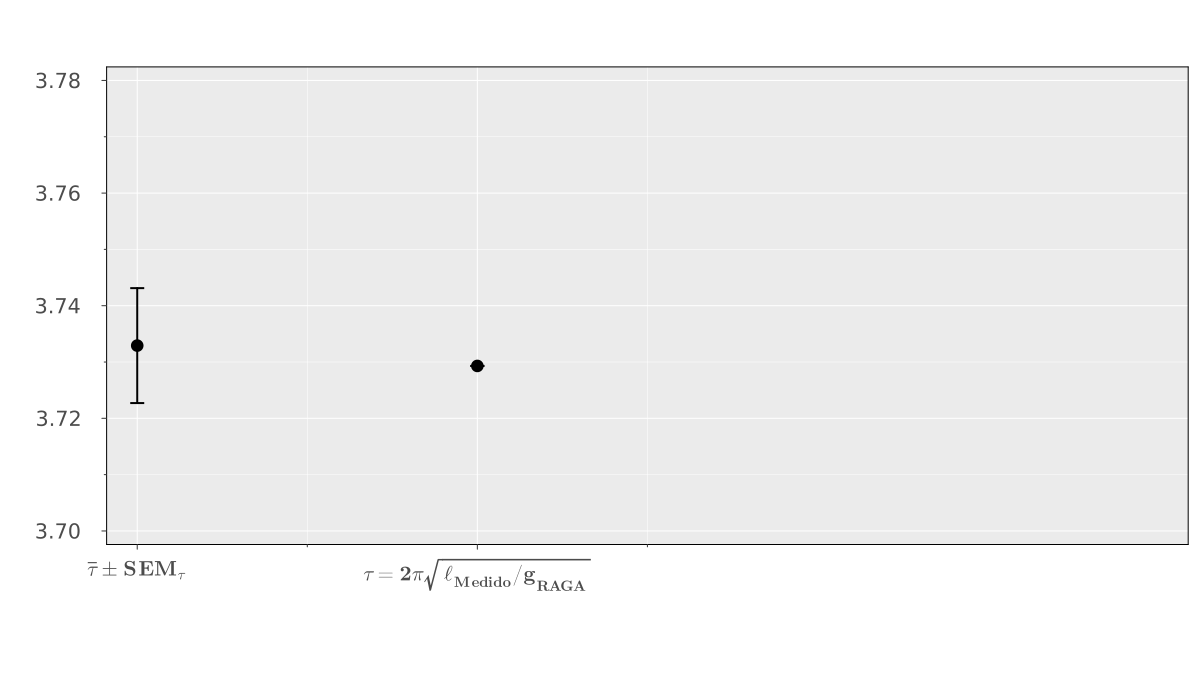

In [50]:
scatter([1,2], [media, τ_modelo],yerror = [SEM,0],markersize = 7, markercolor = :black,linewidth = 2,linecolor = :black,label="",
xticks = ([1,2],[L"\mathbf{\overline{\tau} \pm SEM_{\tau}}",L"\mathbf{\tau = 2\pi \sqrt{\ell_{Medido}/g_{RAGA}}}"]),
    xlim = (1,4), ylim = (3.7,3.78), ylab = L"\tau \; (s)", title = "Comparación entre periodo medido y predicho por el modelo")

#### Otra forma de ver las cosas

Si asumimos que los que midió Nico da por resultado una distribución normal con media $\overline{\tau}$ y desviación estándar $SEM = s_\tau /\sqrt{200}$, tenemos:

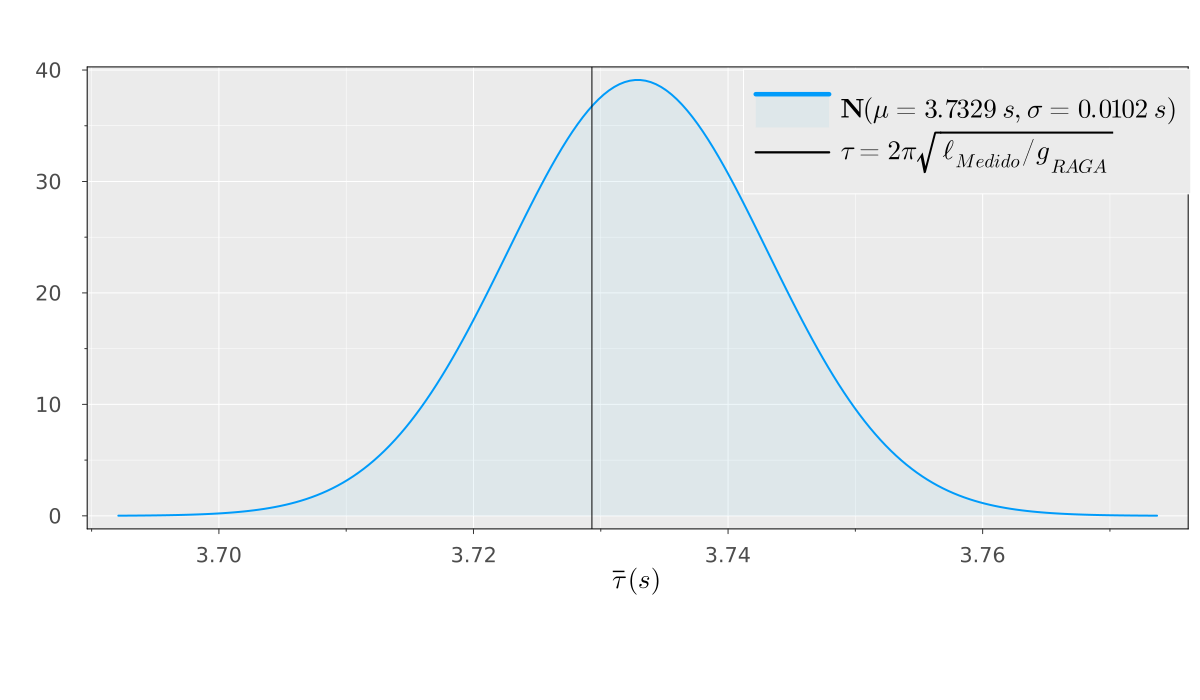

In [74]:
μ = round(media, digits = 4)
σ = round(SEM, digits = 4)
d = Normal(μ, σ)
x = range(μ - 4*σ, μ + 4*σ, length=200)
plot(x, pdf.(d, x), fill=(0, 0.2, :lightblue),label=L"\mathbf{N}(μ=%$μ \;s, σ=%$σ \; s)", lw=2, xlab = L"\overline{\tau} \; (s)", 
legend_position = (0.685,0.905))
vline!([τ_modelo], color = :black, label = L"\tau = 2\pi \sqrt{\ell_{Medido}/g_{RAGA}}")
